In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pyxdf
from scipy.signal import welch

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
DATA_DIR = Path('../data')
XDF_FILE = sorted(DATA_DIR.glob('*.xdf'))[0]
EMG_STREAM_NAME = 'OpenEphys_EMG'
CHANNEL_INDEX = 0
FFT_SECONDS = 30.0  # use the first N seconds for the spectrum; set to None for the full file

print(f'Using file: {XDF_FILE.resolve()}')
print(f'EMG stream: {EMG_STREAM_NAME}')
print(f'Channel index: {CHANNEL_INDEX}')

Using file: C:\Users\NML\Documents\Github\sEMG-model\sEMG_sleeve\data\sub-001_ses-002_task-emg2angles_run-001_meg.xdf
EMG stream: OpenEphys_EMG
Channel index: 0


In [3]:
def stream_name(stream):
    info = stream.get('info', {})
    name = info.get('name', [None])
    return name[0] if isinstance(name, list) else name


def stream_srate(stream, default=2000.0):
    info = stream.get('info', {})
    nominal = info.get('nominal_srate', [default])
    nominal = nominal[0] if isinstance(nominal, list) else nominal
    try:
        nominal = float(nominal)
    except (TypeError, ValueError):
        nominal = float(default)
    return nominal if nominal > 0 else float(default)


def get_stream_by_name(streams, name):
    for stream in streams:
        if stream_name(stream) == name:
            return stream
    available = [stream_name(stream) for stream in streams]
    raise KeyError(f"Stream '{name}' not found. Available: {available}")

In [4]:
streams, header = pyxdf.load_xdf(str(XDF_FILE))
print('Available streams:')
for i, stream in enumerate(streams):
    arr = np.asarray(stream.get('time_series', []))
    print(f"  [{i}] {stream_name(stream)} | shape={arr.shape} | nominal_srate={stream_srate(stream):.3f} Hz")

emg_stream = get_stream_by_name(streams, EMG_STREAM_NAME)
emg = np.asarray(emg_stream['time_series'], dtype=np.float32)
ts = np.asarray(emg_stream['time_stamps'], dtype=np.float64)
fs = stream_srate(emg_stream)

if emg.ndim == 1:
    emg = emg[:, None]

print()
print(f'EMG shape: {emg.shape}')
print(f'Nominal sampling rate: {fs:.3f} Hz')
print(f'Duration: {ts[-1] - ts[0]:.3f} s')

Available streams:
  [0] StereoHandTracker_Angles | shape=(18484, 28) | nominal_srate=2000.000 Hz
  [1] StereoHandTracker_Landmarks | shape=(18484, 126) | nominal_srate=2000.000 Hz
  [2] OpenEphys_EMG | shape=(1286144, 128) | nominal_srate=2000.000 Hz

EMG shape: (1286144, 128)
Nominal sampling rate: 2000.000 Hz
Duration: 643.072 s


In [5]:
x = emg[:, CHANNEL_INDEX].astype(np.float64)

if FFT_SECONDS is not None:
    n_keep = min(len(x), int(round(float(FFT_SECONDS) * fs)))
    x = x[:n_keep]
    t = ts[:n_keep] - ts[0]
else:
    t = ts - ts[0]

x = x - np.mean(x)

freqs_fft = np.fft.rfftfreq(len(x), d=1.0 / fs)
fft_mag = np.abs(np.fft.rfft(x))

freqs_psd, psd = welch(x, fs=fs, nperseg=min(8192, len(x)))

print(f'Analyzed samples: {len(x)}')
print(f'Analyzed duration: {len(x) / fs:.3f} s')

Analyzed samples: 60000
Analyzed duration: 30.000 s


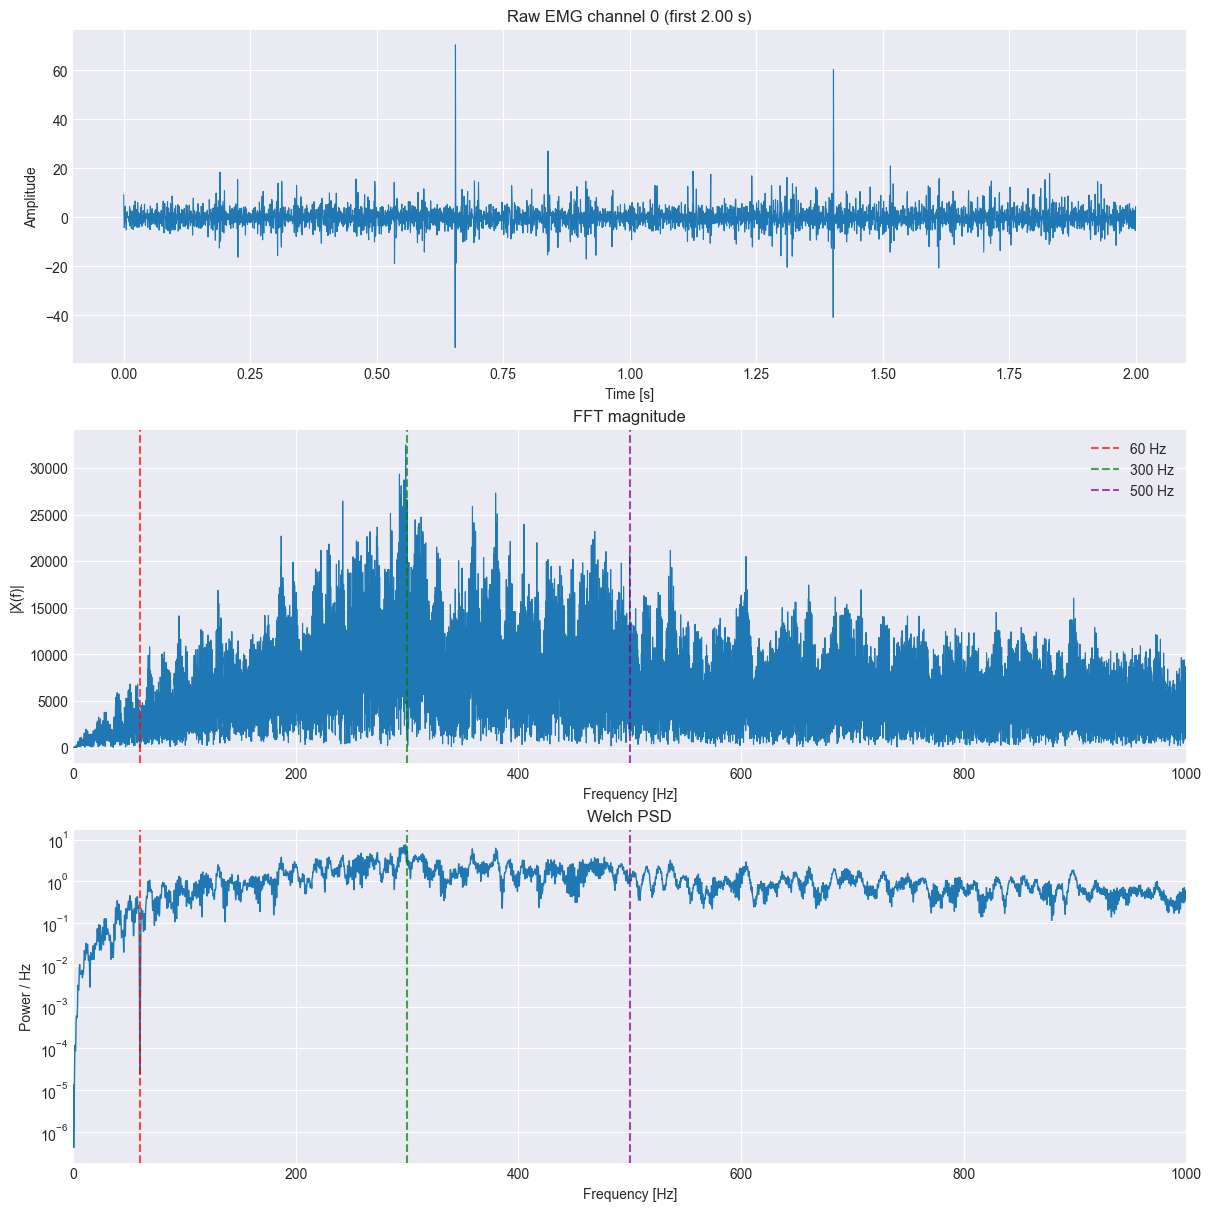

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

time_show = min(len(t), int(fs * 2.0))
axes[0].plot(t[:time_show], x[:time_show], lw=0.8)
axes[0].set_title(f'Raw EMG channel {CHANNEL_INDEX} (first {time_show / fs:.2f} s)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')

axes[1].plot(freqs_fft, fft_mag, lw=0.8)
axes[1].set_xlim(0, min(1000, fs / 2))
axes[1].set_title('FFT magnitude')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('|X(f)|')
axes[1].axvline(60, color='r', ls='--', alpha=0.7, label='60 Hz')
axes[1].axvline(300, color='g', ls='--', alpha=0.7, label='300 Hz')
axes[1].axvline(500, color='purple', ls='--', alpha=0.7, label='500 Hz')
axes[1].legend(loc='upper right')

axes[2].semilogy(freqs_psd, psd, lw=1.0)
axes[2].set_xlim(0, min(1000, fs / 2))
axes[2].set_title('Welch PSD')
axes[2].set_xlabel('Frequency [Hz]')
axes[2].set_ylabel('Power / Hz')
axes[2].axvline(60, color='r', ls='--', alpha=0.7)
axes[2].axvline(300, color='g', ls='--', alpha=0.7)
axes[2].axvline(500, color='purple', ls='--', alpha=0.7)

plt.show()